In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Data/stsbyseasonclean.csv')

df.head(50)

,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,PTS,birth_year,height_cm,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team,drafted
0,NBA,1999 - 2000,Regular_Season,Shaquille O'Neal,LAL,79,3163.0,956,1665,0,...,2344,1972.0,216.0,147.0,United States,Robert G. Cole High School,1.0,1.0,Orlando Magic,1
1,NBA,1999 - 2000,Regular_Season,Vince Carter,TOR,82,3126.0,788,1696,95,...,2107,1977.0,198.0,100.0,United States,Mainland High School,1.0,5.0,Golden State Warriors,1
2,NBA,1999 - 2000,Regular_Season,Karl Malone,UTA,82,2947.0,752,1476,2,...,2095,1963.0,206.0,120.0,United States,Summerfield High School,1.0,13.0,Utah Jazz,1
3,NBA,1999 - 2000,Regular_Season,Allen Iverson,PHI,70,2853.0,729,1733,89,...,1989,1975.0,183.0,75.0,United States,Bethel High School,1.0,1.0,Philadelphia Sixers,1
4,NBA,1999 - 2000,Regular_Season,Gary Payton,SEA,82,3425.0,747,1666,177,...,1982,1968.0,193.0,82.0,United States,Skyline High School,1.0,2.0,Seattle SuperSonics,1
5,NBA,1999 - 2000,Regular_Season,Jerry Stackhouse,DET,82,3148.0,619,1447,83,...,1939,1974.0,198.0,99.0,United States,Oak Hill Academy,1.0,3.0,Philadelphia Sixers,1
6,NBA,1999 - 2000,Regular_Season,Grant Hill,DET,74,2776.0,696,1422,34,...,1906,1972.0,203.0,102.0,United States,South Lakes High School,1.0,3.0,Detroit Pistons,1
7,NBA,1999 - 2000,Regular_Season,Kevin Garnett,MIN,81,3243.0,759,1526,30,...,1857,1976.0,211.0,109.0,United States,Farragut Career Academy,1.0,5.0,Minnesota Timberwolves,1
8,NBA,1999 - 2000,Regular_Season,Michael Finley,DAL,82,3464.0,748,1636,99,...,1855,1973.0,201.0,102.0,United States,Proviso East High School,1.0,21.0,Phoenix Suns,1
9,NBA,1999 - 2000,Regular_Season,Chris Webber,SAC,75,2880.0,748,1548,27,...,1834,1973.0,206.0,111.0,United States,Detroit Country Day School,1.0,1.0,Orlando Magic,1


In [2]:
dff = df.copy()

#### Detectamos Outliers

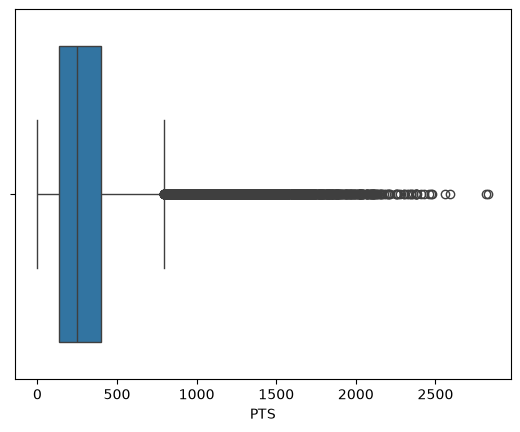

In [3]:
sns.boxplot(x=dff['PTS'])
plt.show()

###### en la caja azul, detectamos donde están la mayoría de los jugadores. La distribución de la derecha nos indican que el otro grupo rompen la barrera de los 1000-2000 puntos.

#### _______________________________________________

In [4]:
cols_num = dff.select_dtypes(include='number').columns

for col in cols_num:
    Q1 = dff[col].quantile(0.25)
    Q3 = dff[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = dff[(dff[col] < Q1 - 1.5 * IQR) | (dff[col] > Q3 + 1.5 * IQR)]

    print(f'{col}: {len(outliers)} outliers') 

GP: 3651 outliers
MIN: 2829 outliers
FGM: 2857 outliers
FGA: 2956 outliers
3PM: 2145 outliers
3PA: 1833 outliers
FTM: 2886 outliers
FTA: 2761 outliers
TOV: 2019 outliers
PF: 2080 outliers
ORB: 3476 outliers
DRB: 3202 outliers
REB: 3106 outliers
AST: 3670 outliers
STL: 2251 outliers
BLK: 4761 outliers
PTS: 2759 outliers
birth_year: 437 outliers
height_cm: 114 outliers
weight_kg: 247 outliers
draft_round: 13 outliers
draft_pick: 0 outliers
drafted: 10136 outliers


#### Como están distribuido los datos?

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
GP,53949.0,30.313574,17.849616,1.0,17.0,29.0,37.0,85.0
MIN,53949.0,752.431404,534.216679,0.0,380.9,663.0,954.0,3485.0
FGM,53949.0,113.200541,100.164033,0.0,48.0,89.0,145.0,978.0
FGA,53949.0,245.094942,212.155076,0.0,109.0,196.0,310.0,2173.0
3PM,53949.0,28.468535,30.673395,0.0,6.0,20.0,41.0,402.0
3PA,53949.0,80.738383,80.672208,0.0,20.0,61.0,117.0,1028.0
FTM,53949.0,56.297299,59.240650,0.0,20.0,40.0,73.0,756.0
FTA,53949.0,76.012716,76.172698,0.0,28.0,56.0,99.0,972.0
TOV,53949.0,47.260487,37.398461,0.0,21.0,39.0,63.0,464.0
PF,53949.0,70.101040,45.629770,0.0,37.0,64.0,91.0,371.0


#### Estadistica de los puntos 'PTS'

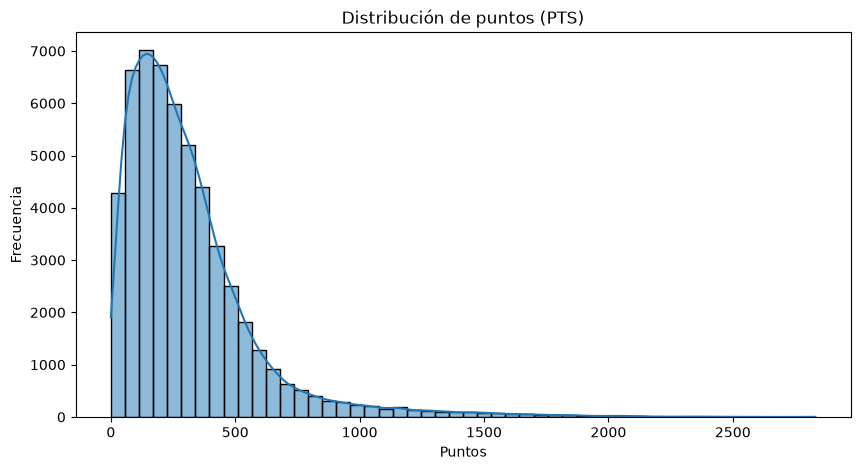

In [6]:
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(df['PTS'], bins=50, kde=True, ax=ax)
ax.set_title('Distribución de puntos (PTS)')
ax.set_xlabel('Puntos')
ax.set_ylabel('Frecuencia')
plt.show()

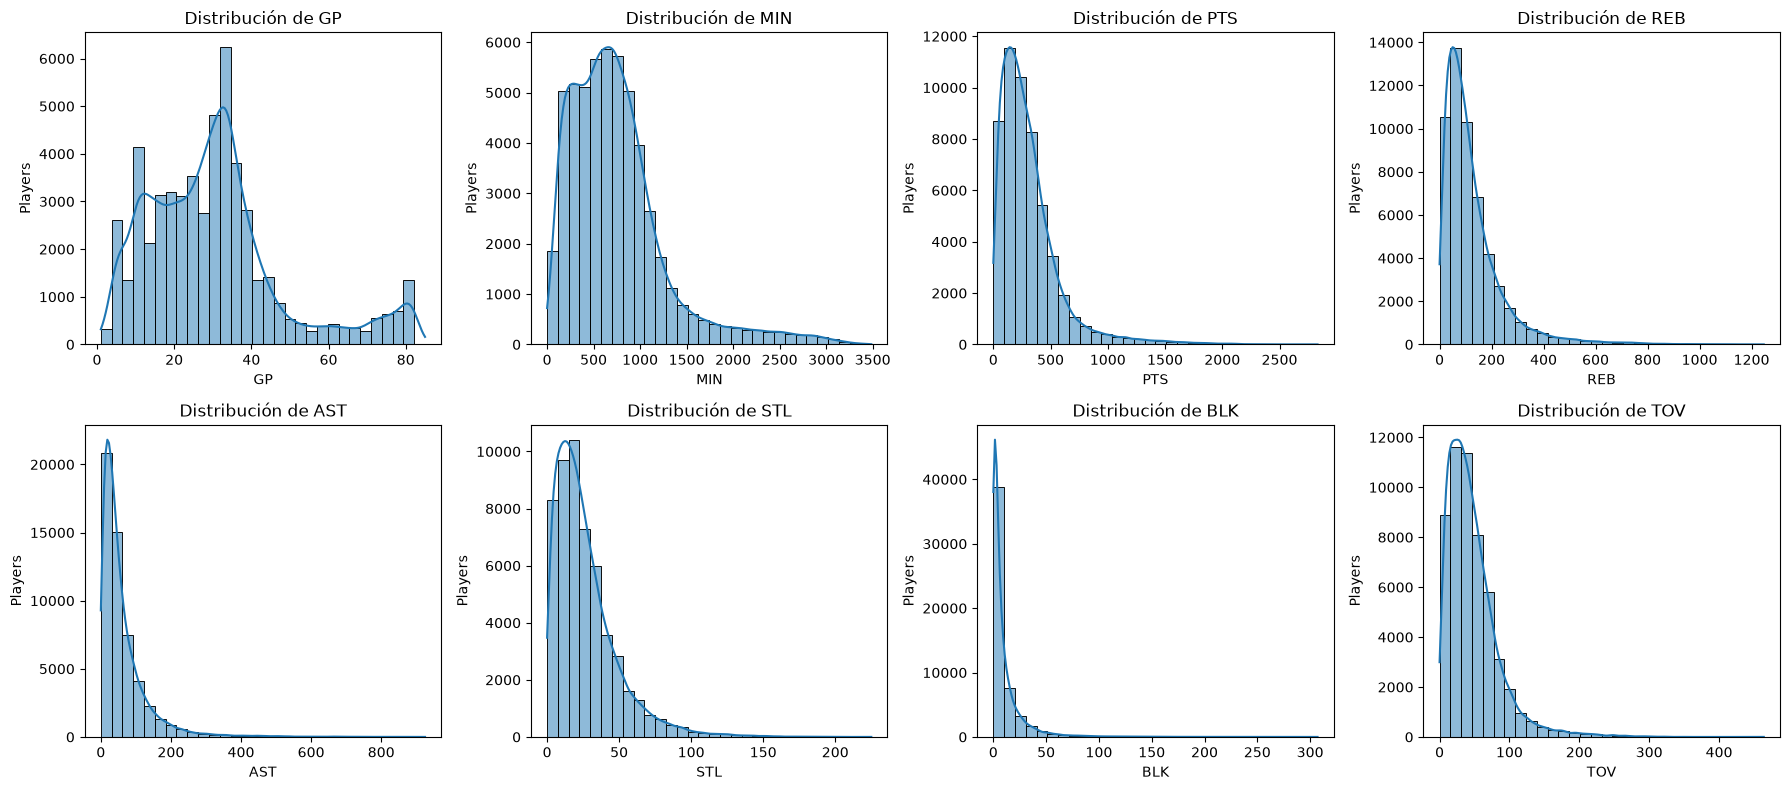

In [7]:
cols_stats = ['GP', 'MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_stats):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Players')

plt.tight_layout()
plt.show()

In [8]:
print("Stage:")
print(df['Stage'].unique())

print("\nLeague:")
print(df['League'].unique())

Stage:
<ArrowStringArray>
['Regular_Season', 'Playoffs', 'International']
Length: 3, dtype: str

League:
<ArrowStringArray>
[                               'NBA',                         'Euroleague',
                            'Eurocup',                     'Australian-NBL',
                         'German-BBL',        'Italian-Lega-Basket-Serie-A',
                        'Spanish-ACB',                  'French-Jeep-Elite',
                 'Argentinian-Liga-A',              'Austrian-A-Bundesliga',
                         'Balkan-BIL',                     'Belarusian-BPL',
             'Belgium-Scooore-League',                   'Bosnian-BiH-Liga',
                      'Brazilian-NBB',                        'British-BBL',
                      'Bulgarian-NBL',                       'Canadian-NBL',
                        'Chinese-CBA',                  'Croatian-A-1-Liga',
                          'Czech-NBL',                'Danish-Basketligaen',
                 'Finnish-Kor

#### Con estos datos podemos preguntarnmos: <br> El top 10 registros de Ligas <br> Cuales son las ligas con más puntos anotados <br> cuales son los promedios de puntos por 'Stage'.

In [9]:
print(dff['League'].value_counts().head(10))

League
NBA                            7633
Eurocup                        4136
Euroleague                     3322
Spanish-ACB                    2328
Australian-NBL                 2022
German-BBL                     2022
Italian-Lega-Basket-Serie-A    1865
French-Jeep-Elite              1852
Chinese-CBA                    1426
FIBA-Europe-Cup                1388
Name: count, dtype: int64


#### Agrupamos todos los jugadores por liga seleccionando la columna de puntos. <br> calculamos el promedio de PTOS y lo ordenamos de mayor a menor

In [10]:
dff.groupby('League')['PTS'].mean().sort_values(ascending=False).head(10)

League
NBA                    553.939735
South-Korean-KBL       461.339744
Chinese-CBA            436.413043
Canadian-NBL           433.515539
Argentinian-Liga-A     424.691077
Japanese-BLeague       412.576985
Finnish-Korisliiga     409.578871
Mexican-LNBP           381.422222
Swedish-Basketligan    365.440252
Slovakian-Extraliga    356.303538
Name: PTS, dtype: float64

#### Agrupamos todos los jugadores por liga seleccionando la columna de puntos. <br> calculamos el promedio de PTOS en los Stages 

In [11]:
dff.groupby('Stage')['PTS'].mean().sort_values(ascending=False)

Stage
Regular_Season    837.150708
International     271.170654
Playoffs          110.512269
Name: PTS, dtype: float64

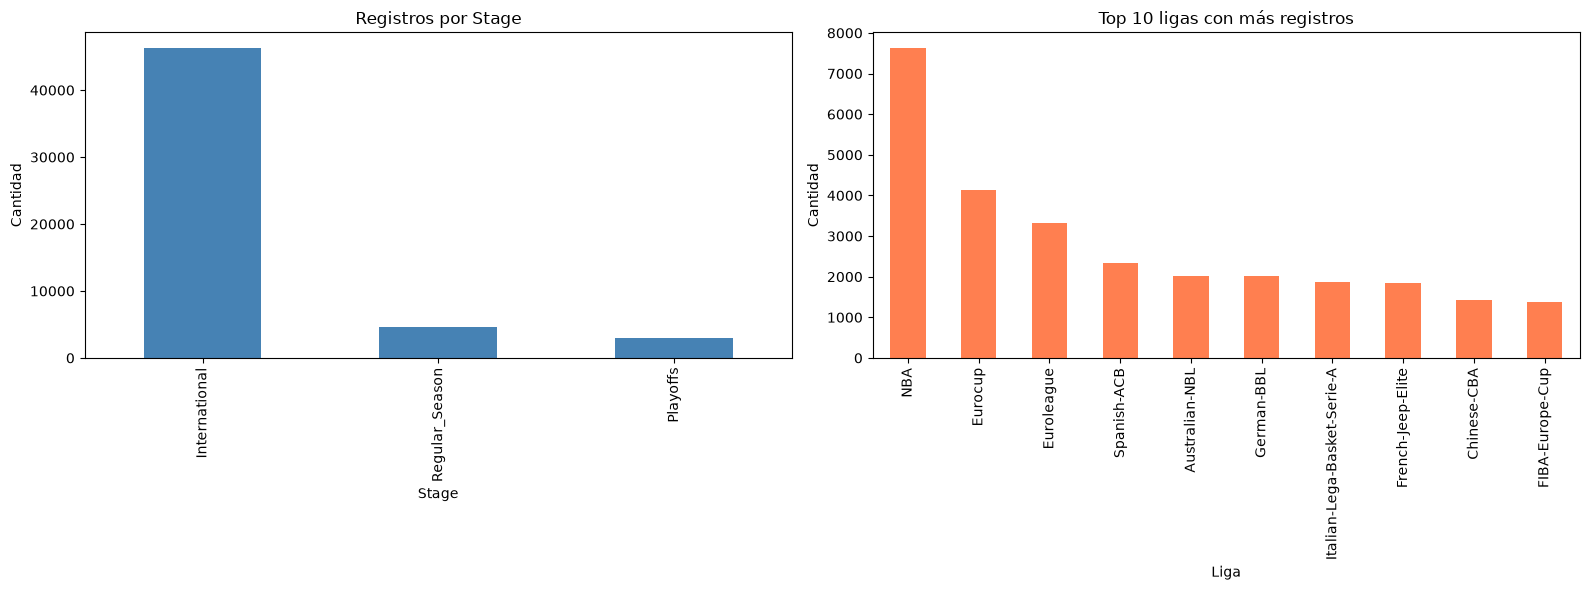

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Registros por Stage

dff['Stage'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Registros por Stage')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Cantidad')

# Top 10 Ligas

dff['League'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 ligas con más registros')
axes[1].set_xlabel('Liga')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

###### Al ver las grafías, en la de TOP ligas con más registros, <br> sería descabellado comparar una liga como la NBA con casi 8.000 registros con la de Luxemburgo que no llega a los 50, por ejemplo 

#### Pienso que dentro de Internacional son las ligas internacionales diferentes a la NBA. Por consiguiente, nos informamos para cerciorarnos de ello.

In [13]:
print(df[df['Stage'] == 'International']['League'].value_counts().head(20))

League
Eurocup                        4136
Euroleague                     3322
Spanish-ACB                    2328
Australian-NBL                 2022
German-BBL                     2022
Italian-Lega-Basket-Serie-A    1865
French-Jeep-Elite              1852
Chinese-CBA                    1426
FIBA-Europe-Cup                1388
Argentinian-Liga-A             1188
Serbian-KLS                    1022
Brazilian-NBB                  1011
Polish-TBL                      978
Turkish-BSL                     977
Greek-HEBA-A1                   870
Croatian-A-1-Liga               819
Hungarian-NBIA                  818
Czech-NBL                       802
Mexican-LNBP                    765
Romanian-Divizia-A              760
Name: count, dtype: int64


#### Creamos una copia del DF para separar la NBA de las internacionales

In [14]:
dfc = dff.copy()

In [15]:
df_nba = dfc[dfc['League'] == 'NBA'].copy()
df_int = dfc[dfc['Stage'] == 'International'].copy()

In [16]:
print(f"dfc    : {dfc.shape[0]} filas")
print(f"df_nba  : {df_nba.shape[0]} filas")
print(f"df_int : {df_int.shape[0]} filas")

dfc    : 53949 filas
df_nba  : 7633 filas
df_int : 46316 filas


###### Como vimos antes, en el df_int están casi todas las ligas, sin embarggo en nba... está solamente nba

In [17]:
dfc

,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,PTS,birth_year,height_cm,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team,drafted
0,NBA,1999 - 2000,Regular_Season,Shaquille O'Neal,LAL,79,3163.0,956,1665,0,...,2344,1972.0,216.0,147.0,United States,Robert G. Cole High School,1.0,1.0,Orlando Magic,1
1,NBA,1999 - 2000,Regular_Season,Vince Carter,TOR,82,3126.0,788,1696,95,...,2107,1977.0,198.0,100.0,United States,Mainland High School,1.0,5.0,Golden State Warriors,1
2,NBA,1999 - 2000,Regular_Season,Karl Malone,UTA,82,2947.0,752,1476,2,...,2095,1963.0,206.0,120.0,United States,Summerfield High School,1.0,13.0,Utah Jazz,1
3,NBA,1999 - 2000,Regular_Season,Allen Iverson,PHI,70,2853.0,729,1733,89,...,1989,1975.0,183.0,75.0,United States,Bethel High School,1.0,1.0,Philadelphia Sixers,1
4,NBA,1999 - 2000,Regular_Season,Gary Payton,SEA,82,3425.0,747,1666,177,...,1982,1968.0,193.0,82.0,United States,Skyline High School,1.0,2.0,Seattle SuperSonics,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53944,Ukrainian-Superleague,2019 - 2020,International,Kyrylo Meshheryakov,MYK,15,127.0,7,28,2,...,19,1995.0,198.0,83.0,Ukraine,Unknown,NaN,NaN,Undrafted,0
53945,Ukrainian-Superleague,2019 - 2020,International,Yaroslav Kadygrob,ODE,10,81.7,5,16,4,...,15,1991.0,191.0,85.0,Ukraine,Unknown,NaN,NaN,Undrafted,0
53946,Ukrainian-Superleague,2019 - 2020,International,Ernesto Tkachuk,ODE,16,124.7,1,15,0,...,9,1994.0,188.0,91.0,Ukraine,Unknown,NaN,NaN,Undrafted,0
53947,Ukrainian-Superleague,2019 - 2020,International,Andrij Shapovalov,KHAR,12,59.2,0,8,0,...,3,1993.0,188.0,78.0,Ukraine,Unknown,NaN,NaN,Undrafted,0


#### Cuales son el top 5 de mejores ligas de internacionales <br> luego comparamos con la NBA a ver cual se podría considerar la más atractiva del mundo.(En muntos) <br> En qué liga juegan los mejores jugadores. <br> cuales son el top 5 de mejores equipos internacionales y comparar los equipos con el mejor de la NBA. <br> con que edad es el prime de los jugadores en NBA e internacionalmente y comprararlo

## Creamos métrica de rendimiento de las ligas internacionales

In [44]:

df_int['performance'] = df_int['PTS'] + df_int['REB'] + df_int['AST'] + df_int['STL'] + df_int['BLK']

In [ ]:
# Ajustamos la metrica de rendimiento por los minutos jugados
# >1.0 → jugador muy productivo por minuto // 0.5 – 1.0 → buen rendimiento // <0.5 → rendimiento bajo

df_int['performpermin'] = df_int['performance'] / df_int['MIN']

#### TOP 5 LIGAS

In [36]:
top5_l = df_int.groupby('League')['performpermin'].mean().sort_values(ascending=False).head(5).reset_index()

top5_l.columns = ['Liga', 'Performance']
top5_l['Performance'] = top5_l['Performance'].round(2)

In [37]:
top5_l

,Liga,Performance
0,New-Zealand-NBL,0.77
1,Canadian-NBL,0.76
2,Belarusian-BPL,0.74
3,British-BBL,0.73
4,Lebanese-Division-A,0.72


#### Generamos un gráfico que muestre el rendimiento promedio por minuto de cada liga

In [31]:
liga_perf = (
    df_int.groupby('League')['performpermin']
         .mean()
         .sort_values(ascending=False)
         .reset_index()
)

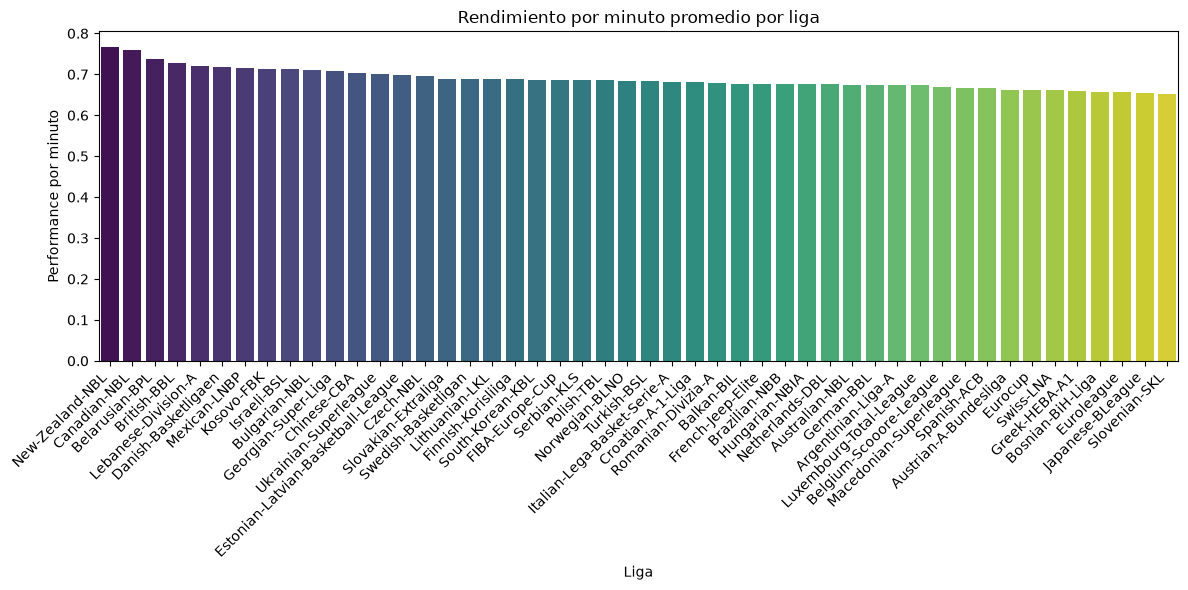

In [43]:
plt.figure(figsize=(12,6))
sns.barplot(data=liga_perf, 
            x='League', 
            y='performpermin',
            hue='League', 
            palette='viridis',
            legend=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Rendimiento por minuto promedio por liga')
plt.ylabel('Performance por minuto')
plt.xlabel('Liga')

plt.tight_layout()
plt.show()

###### Como podemos comprobar, el promedio de los jugadores de las top 5 primeras ligas tienen un buen rendimiento, por encima de 0,5 pero por debajo del 1. <br> Por lo que, estas tienen un mayor rendimiento promedio por minuto.

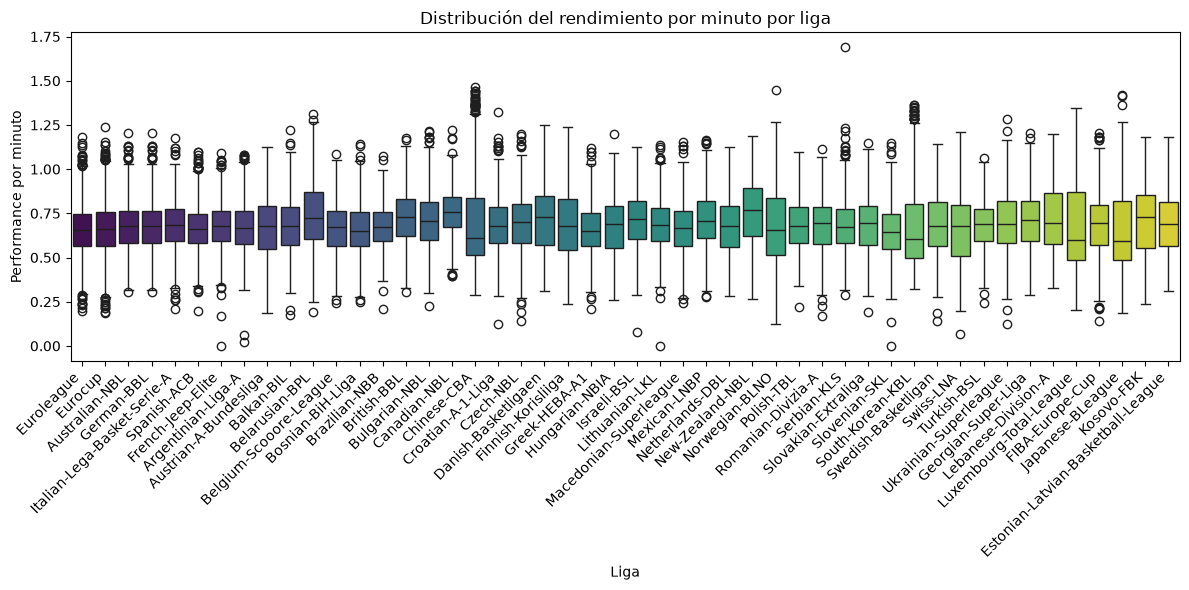

In [40]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_int,
    x='League',
    y='performpermin',
    hue='League',
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Distribución del rendimiento por minuto por liga')
plt.xlabel('Liga')
plt.ylabel('Performance por minuto')

plt.tight_layout()
plt.show()


###### En la gráfica de arriba, vemos como se distribuye el rendimiento dentro de cada liga. como vemos hay muchos outliers, puyesto que hay jugadores muy buenos y jugadores muy malos dentro de cada una.

#### Quienes son el top 1 de jugadores de cada liga y de qué temporada (año es)

In [46]:
top1_perform = (
    df_int.loc[
        df_int.groupby('League')['performpermin'].idxmax(),
        ['League', 'Player', 'performpermin', 'Season']
    ]
    .sort_values('performpermin', ascending=False)
    .reset_index(drop=True)
)

top1_perform

,League,Player,performpermin,Season
0,Serbian-KLS,William Lee,1.689498,2018 - 2019
1,Chinese-CBA,Darius Adams,1.461988,2019 - 2020
2,Norwegian-BLNO,Erik Borg,1.447876,2019 - 2020
3,Japanese-BLeague,Davante Gardner,1.418412,2017 - 2018
4,South-Korean-KBL,Aaron Haynes,1.365348,2019 - 2020
5,Luxembourg-Total-League,Duane Johnson,1.346252,2019 - 2020
6,Croatian-A-1-Liga,Marko Tomas,1.322437,2018 - 2019
7,Belarusian-BPL,Devin Johnson,1.314564,2019 - 2020
8,Ukrainian-Superleague,Q.J. Peterson,1.281651,2019 - 2020
9,Danish-Basketligaen,Bonell Colas,1.250121,2012 - 2013


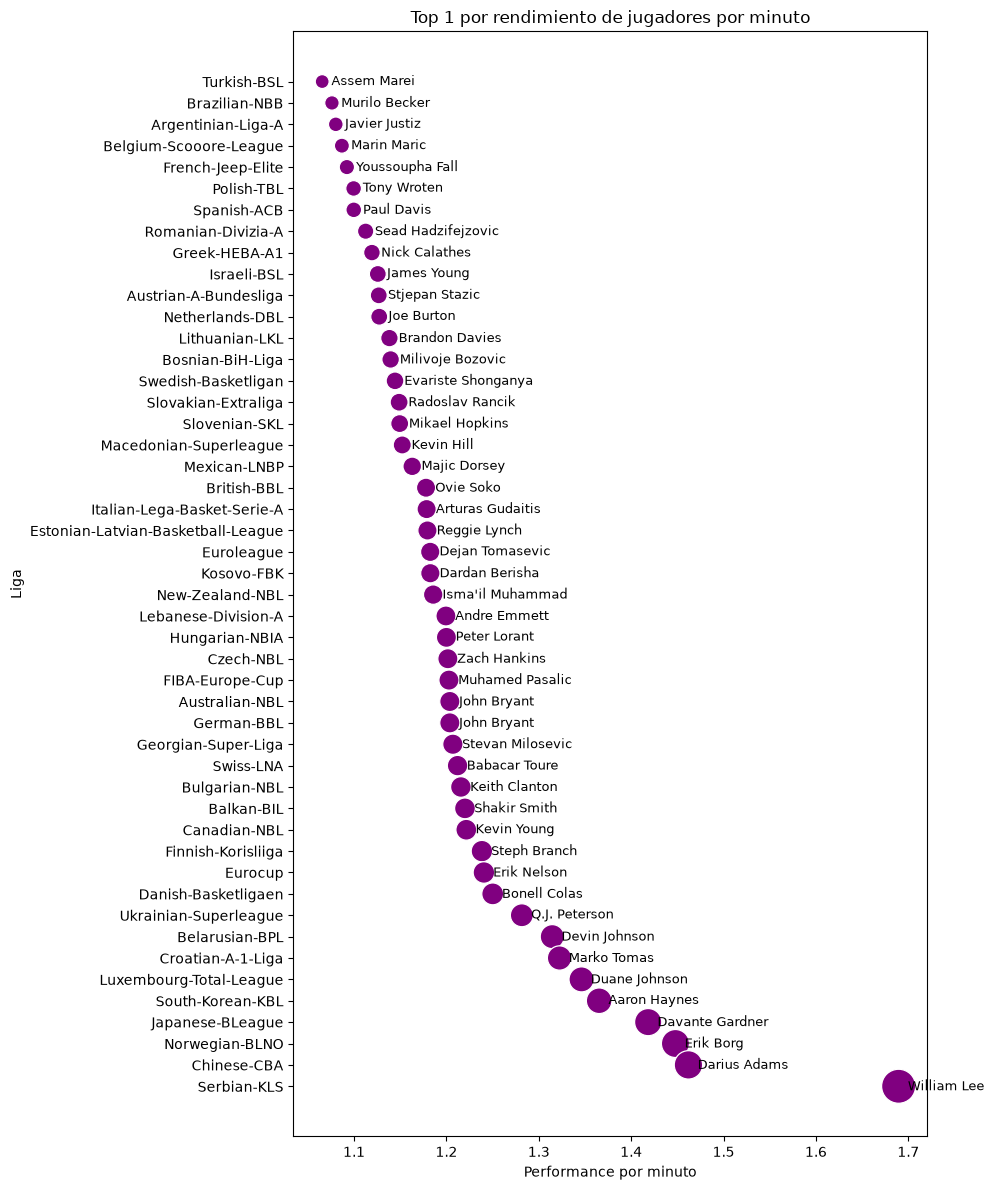

In [54]:
top1_sorted = top1_perform.sort_values('performpermin')

plt.figure(figsize=(10,12))

sns.scatterplot(
    data=top1_sorted,
    x='performpermin',
    y='League',
    size='performpermin',
    sizes=(100, 600),
    color='purple',
    legend=False
)

for i, row in top1_sorted.iterrows():
    plt.text(
        row['performpermin'] + 0.01,
        row['League'],
        row['Player'],
        va='center',
        fontsize=9
    )

plt.title('Top 1 por rendimiento de jugadores por minuto')
plt.xlabel('Performance por minuto')
plt.ylabel('Liga')

plt.tight_layout()
plt.show()



## Creamos metrica de rendimiento NBA